Time series forecasting is used to predict future values based on past data. In this assignment, two popular models are applied:

ARIMA model (AutoRegressive Integrated Moving Average)

SARIMA model (Seasonal ARIMA)



Dataset Loading

In [17]:
import pandas as pd

df = pd.read_csv("/content/test.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Aggregate 'number_sold' by Date to create a unique daily time series
ns = df.groupby(level=0)['number_sold'].sum()

In [18]:
df.isnull().sum()

,0
store,0
product,0
number_sold,0


In [19]:
df.tail()

,store,product,number_sold
Date,,,
2019-12-27,6,9,901
2019-12-28,6,9,926
2019-12-29,6,9,913
2019-12-30,6,9,899
2019-12-31,6,9,886


In [20]:
df.dropna(axis=0,inplace=True)

In [21]:
df.isnull().sum()

,0
store,0
product,0
number_sold,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25550 entries, 2019-01-01 to 2019-12-31
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   store        25550 non-null  int64
 1   product      25550 non-null  int64
 2   number_sold  25550 non-null  int64
dtypes: int64(3)
memory usage: 798.4 KB


In [23]:
train = ns[:'2019-10-01']
test = ns['2019-10-02':]

<Figure size 1000x400 with 0 Axes>

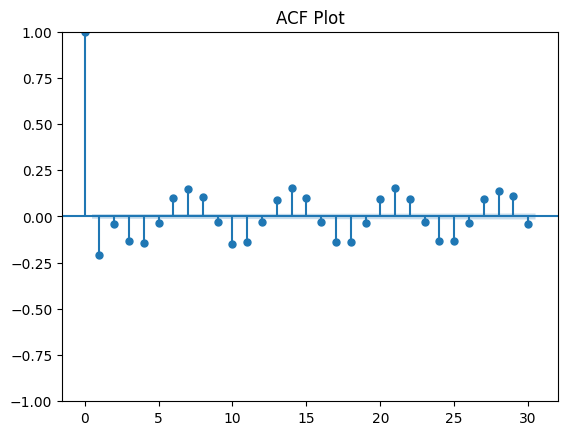

In [24]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(ts.diff().dropna(), lags=30)
plt.title("ACF Plot")
plt.show()

<Figure size 1000x400 with 0 Axes>

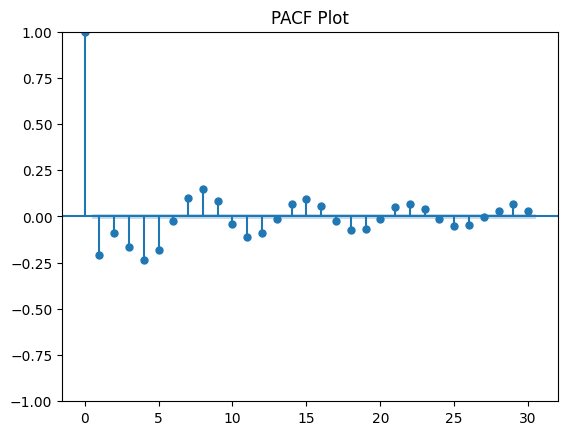

In [25]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,4))
plot_pacf(ts.diff().dropna(), lags=30)
plt.title("PACF Plot")
plt.show()

In [26]:
from statsmodels.tsa.arima.model import ARIMA

# Example order (p,d,q)
model_arima = ARIMA(train, order=(2,1,2))
model_arima_fit = model_arima.fit()

# Forecast
forecast_arima = model_arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

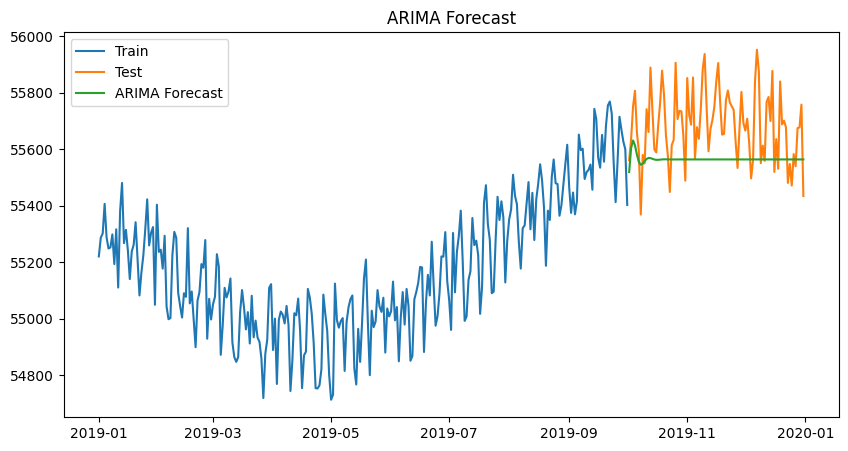

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train,
                      order=(2,1,2),
                      seasonal_order=(1,1,1,12))

model_sarima_fit = model_sarima.fit()

forecast_sarima = model_sarima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


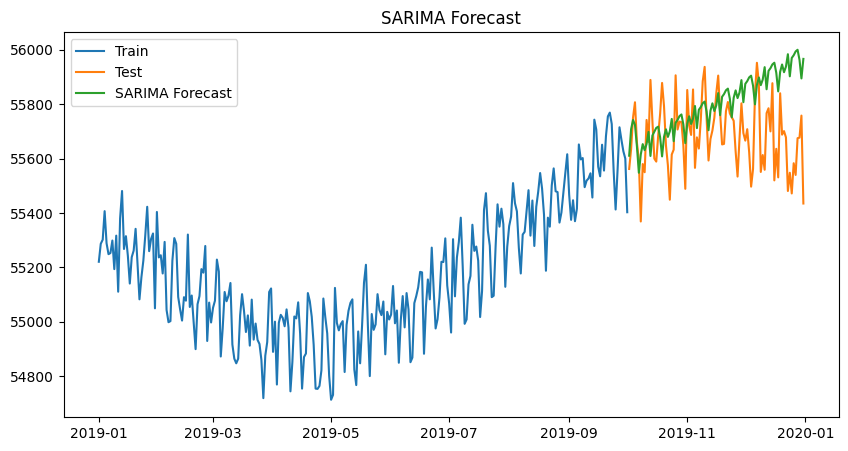

In [29]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast_sarima, label='SARIMA Forecast')
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 170.8925029453295
SARIMA RMSE: 202.91786176827856
